In [2]:
import pandas as pd

df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [3]:
# Check blank values

print((df['TotalCharges'] == ' ').sum())

# Convert to numeric

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check null values after conversion

print(df['TotalCharges'].isnull().sum())

11
11


In [4]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_2886/2840544469.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [5]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [7]:
df['RevenuePerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

In [8]:
def tenure_group(x):
    if x <= 12:
        return "New"
    elif x <= 36:
        return "Medium"
    else:
        return "Loyal"

df['TenureGroup'] = df['tenure'].apply(tenure_group)

In [9]:
def charge_segment(x):
    if x < 35:
        return "Low"
    elif x < 70:
        return "Medium"
    else:
        return "High"

df['ChargeSegment'] = df['MonthlyCharges'].apply(charge_segment)

In [10]:
print("Total Customers :", len(df))

print("Churn Customers :", df[df['Churn']=='Yes'].shape[0])

print("Churn Rate :",
      round(
          df[df['Churn']=='Yes'].shape[0]
          / len(df) * 100,
          2
      ),
      "%"
)

Total Customers : 7043
Churn Customers : 1869
Churn Rate : 26.54 %


In [11]:
revenue_lost = df[df['Churn']=='Yes']['TotalCharges'].sum()

print("Revenue Lost Due To Churn:")
print(round(revenue_lost,2))

Revenue Lost Due To Churn:
2862926.9


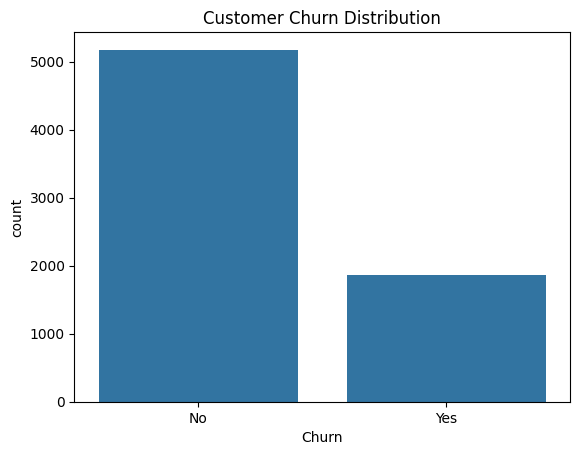

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.show()

Most customers are retained, but a significant percentage have churned, indicating customer retention challenges.

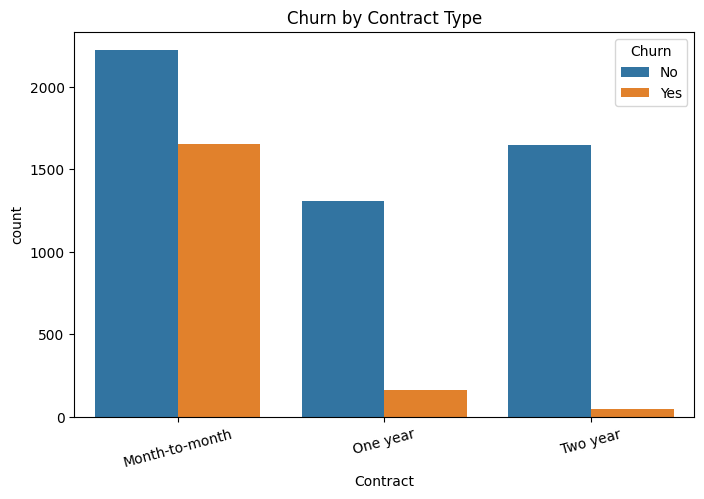

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title('Churn by Contract Type')
plt.xticks(rotation=15)
plt.show()

Month-to-month customers are much more likely to churn than customers with yearly contracts.

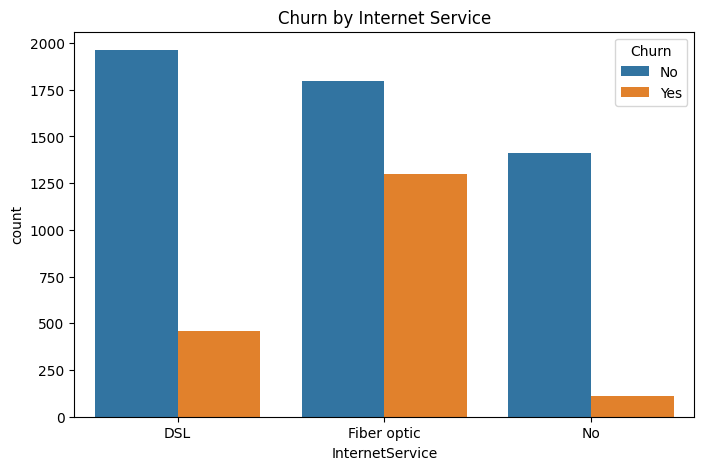

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.title('Churn by Internet Service')
plt.show()

Fiber optic customers often show higher churn despite higher service adoption.

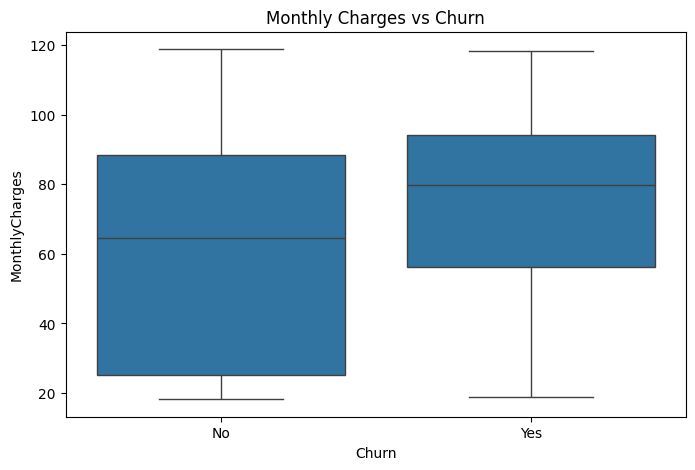

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title('Monthly Charges vs Churn')
plt.show()

Customers with higher monthly charges tend to churn more frequently.

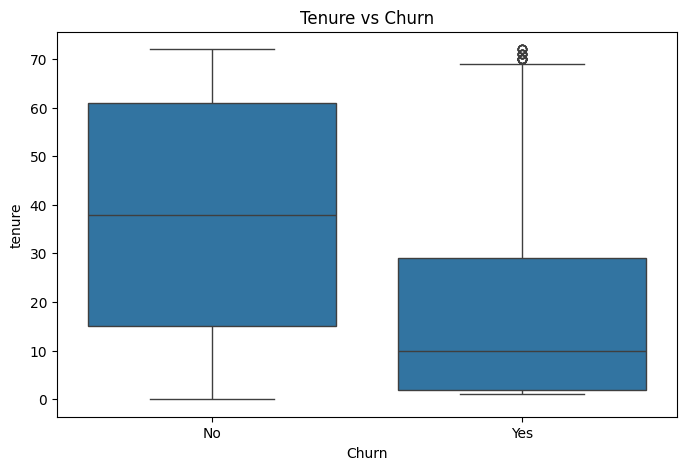

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.title('Tenure vs Churn')
plt.show()

New customers churn significantly more than long-term customers.

In [18]:
df_heat = df.copy()

for col in df_heat.columns:
    if df_heat[col].dtype == 'object':
        df_heat[col] = df_heat[col].astype('category').cat.codes

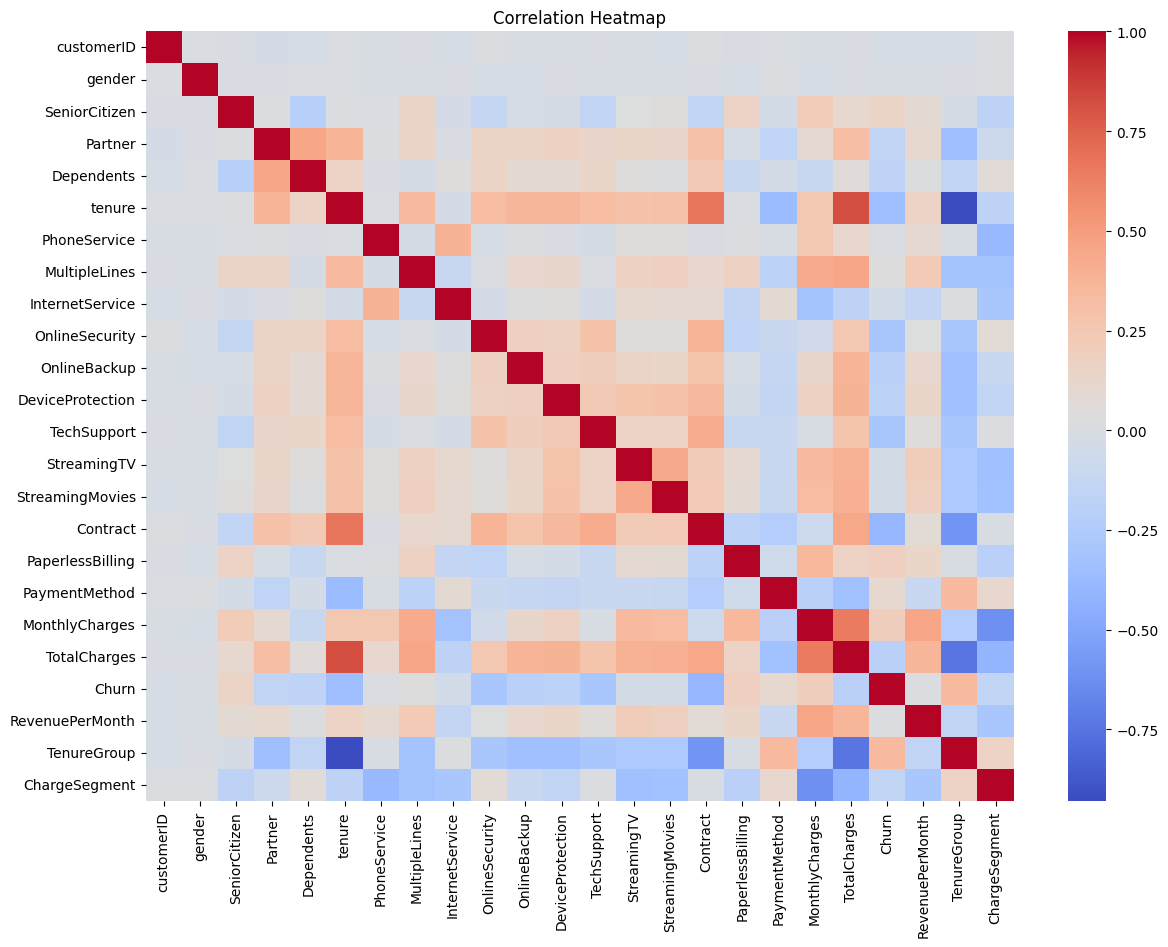

In [19]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df_heat.corr(),
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [20]:
print(pd.crosstab(df['Contract'], df['Churn']))

print("\n")

print(pd.crosstab(df['PaymentMethod'], df['Churn']))

print("\n")

print(pd.crosstab(df['InternetService'], df['Churn']))

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308


Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113


Total Customers: 7043

Churn Rate: 26.54%

Duplicate Records: 0

Highest Churn: Month-to-Month Contract Customers

In [21]:
total_customers = len(df)

active_customers = len(df[df['Churn']=='No'])

churn_customers = len(df[df['Churn']=='Yes'])

total_revenue = df['TotalCharges'].sum()

revenue_lost = df[df['Churn']=='Yes']['TotalCharges'].sum()

avg_monthly_revenue = df['MonthlyCharges'].mean()

print("Total Customers:", total_customers)
print("Active Customers:", active_customers)
print("Churn Customers:", churn_customers)
print("Total Revenue:", round(total_revenue,2))
print("Revenue Lost:", round(revenue_lost,2))
print("Average Monthly Charge:", round(avg_monthly_revenue,2))

Total Customers: 7043
Active Customers: 5174
Churn Customers: 1869
Total Revenue: 16071540.92
Revenue Lost: 2862926.9
Average Monthly Charge: 64.76


In [22]:
print(pd.crosstab(df['Contract'],df['Churn'],normalize='index')*100)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [23]:
print(pd.crosstab(df['InternetService'],df['Churn'],normalize='index')*100)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


In [24]:
print(pd.crosstab(df['PaymentMethod'],df['Churn'],normalize='index')*100)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


In [25]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

le = LabelEncoder()

for col in df_ml.columns:
    if df_ml[col].dtype == 'object':
        df_ml[col] = le.fit_transform(df_ml[col])

In [26]:
X = df_ml.drop('Churn', axis=1)

y = df_ml['Churn']

In [27]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall   :",recall_score(y_test,y_pred))
print("F1 Score :",f1_score(y_test,y_pred))

print(confusion_matrix(y_test,y_pred))

Accuracy : 0.8112136266855926
Precision: 0.6720257234726688
Recall   : 0.5603217158176944
F1 Score : 0.6111111111111112
[[934 102]
 [164 209]]


Customer Metrics
Total Customers: 7043
Churn Rate: 26.54%
Active Customers: 5174
Churned Customers: 1869

Revenue Metrics
Total Revenue: ₹16.07 Million
Revenue Lost Due To Churn: ₹2.86 Million

The company lost approximately ₹2.86 million in revenue due to customer churn, representing nearly 18% of total revenue generated.

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

print("Accuracy :",accuracy_score(y_test,rf_pred))
print("Precision:",precision_score(y_test,rf_pred))
print("Recall   :",recall_score(y_test,rf_pred))
print("F1 Score :",f1_score(y_test,rf_pred))

print(confusion_matrix(y_test,rf_pred))

Accuracy : 0.7977288857345636
Precision: 0.658273381294964
Recall   : 0.4906166219839142
F1 Score : 0.5622119815668203
[[941  95]
 [190 183]]


In [32]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

            Feature  Importance
19     TotalCharges    0.124787
18   MonthlyCharges    0.119614
20  RevenuePerMonth    0.114833
5            tenure    0.114809
0        customerID    0.106480
15         Contract    0.058603
9    OnlineSecurity    0.040721
17    PaymentMethod    0.038038
12      TechSupport    0.035700
21      TenureGroup    0.034630


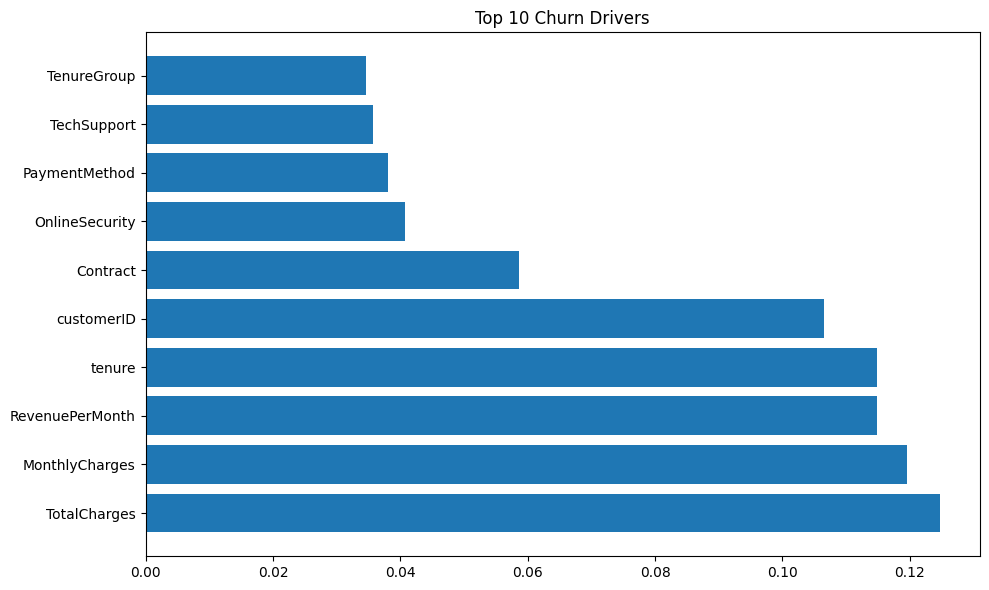

In [33]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.title("Top 10 Churn Drivers")
plt.tight_layout()

plt.show()

In [35]:
from google.colab import files

df.to_csv('customer_churn_cleaned.csv', index=False)
files.download('customer_churn_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'RevenuePerMonth', 'TenureGroup', 'ChargeSegment']


In [37]:
df.to_csv(
    "customer_churn_cleaned.csv",
    index=False,
    encoding="utf-8"
)